## BTSP in an open field (2-comp)
- Add more signals (e.g., novelty, boundaries)
- Add transition changes, e.g., sudden removal of obstacles
- Measure features of CA1 activity (skewness, etc.)

In [1]:
import copy
import random
import time
import warnings

from tqdm import tqdm
from matplotlib import pyplot as plt
import numpy as np
import ratinabox

from predhpc import agent, env, run_manager, plot_util, util, params_util
from predhpc.neurons import riab_neurons, object_neurons, learning_neurons, two_comp_neurons

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

## Reload

In [3]:
import importlib
importlib.reload(agent)
importlib.reload(env)
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(util)
importlib.reload(plot_util);

## Initialise environment

/home/cgillon/Documents/predhpc/predhpc/env.py:1407: EnvironmentWarning: add_walls() does not check whether a new wall will create a hole in the environment. Be sure to check environment visually.
  warnings.warn(


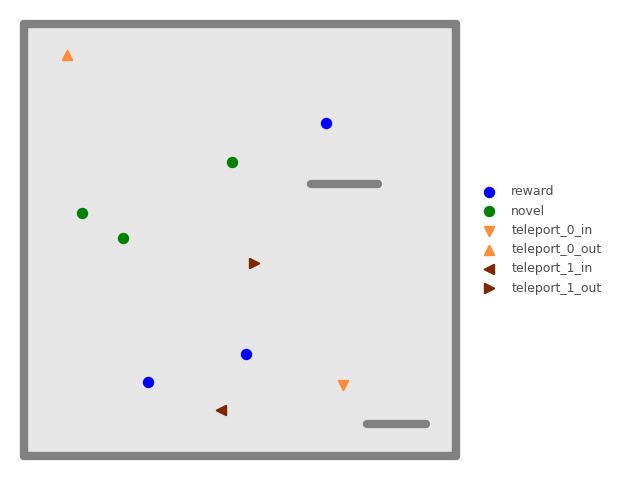

In [4]:
env_params = params_util.get_env_params(
    environment="openfield",
    init_random_reward_obj=3,
    init_random_novel_obj=3,
    init_random_teleport_pairs=2,
    init_random_walls=2,
    init_seed=65
)
Env = env.OpenField(params=env_params)

sub_ax_env = Env.plot_environment();

In [5]:
DT = params_util.DT
SCALE = params_util.SCALE
MAX_NUM_STEPS = 12000

agent_params = params_util.get_agent_params(
    dt=DT,
    scale=SCALE,
    speed_mean=0.08,
    speed_std=0.05,
    environment="openfield", 
    trajectory_length=(MAX_NUM_STEPS + 1)
)

Ag = agent.OpenFieldAgent(Env, params=agent_params)

In [6]:
Ag.get_target_probability_df()

,object_df_idx,object_type_num,object_type_name,idx_within_type,position_x,position_y,teleport_pair_num,teleport_direction,target_factor,target_probability
0,0.0,0.0,reward,0.0,0.287125,0.172645,NaN,NaN,5,0.217391
1,1.0,0.0,reward,1.0,0.699314,0.771511,NaN,NaN,5,0.217391
2,2.0,0.0,reward,2.0,0.514552,0.235807,NaN,NaN,5,0.217391
3,3.0,1.0,novel,0.0,0.230040,0.505715,NaN,NaN,1,0.043478
4,4.0,1.0,novel,1.0,0.134185,0.561462,NaN,NaN,1,0.043478
5,5.0,1.0,novel,2.0,0.482000,0.679669,NaN,NaN,1,0.043478
6,NaN,NaN,no_target,NaN,NaN,NaN,NaN,NaN,5,0.217391


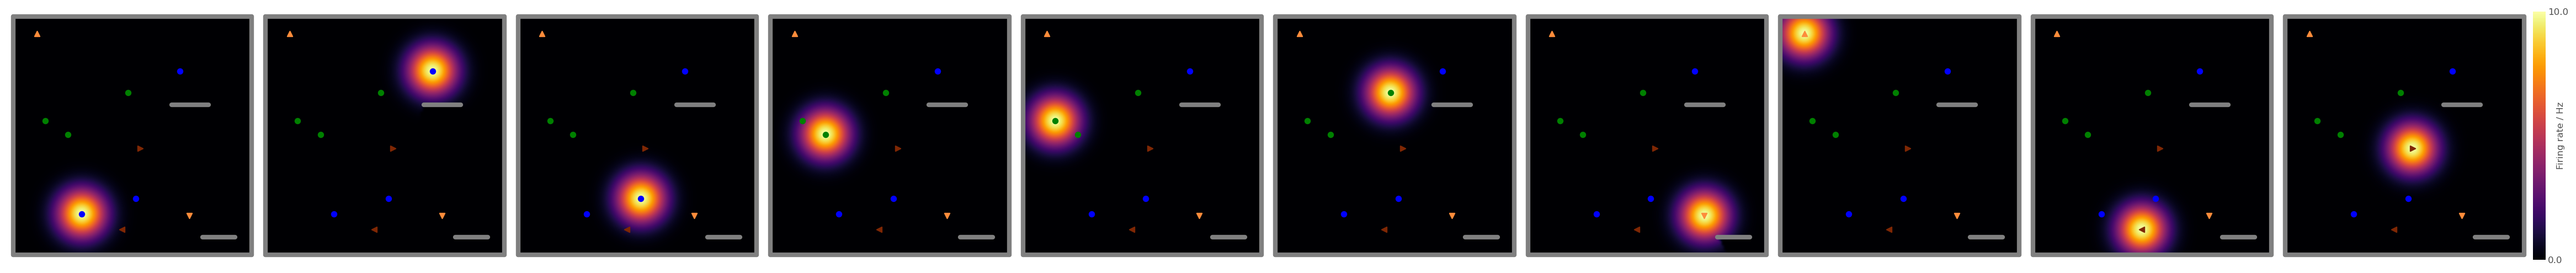

In [7]:
EC_params = params_util.get_EC_params(
    environment="openfield", 
    widths=0.07,
    # teleport_weight=0,
)

CA3_PC_params = params_util.get_CA3_PC_params(
    environment="openfield",
    n=30**2,
)

# ECs = object_neurons.WeightedObjectCells(Ag, params=EC_params)
ECs = object_neurons.ObjectInstanceCells(Ag, params=EC_params)
ECs.plot_rate_map(shape=(ECs.n, 1), no_legend=True)

CA3_PCs = riab_neurons.PlaceCells(Ag, params=CA3_PC_params)

Hebbian_learn = False
CA1_params = params_util.get_CA1_params(
    n=ECs.n,
    environment="openfield", 
    two_compartment=True, 
    BTSP=True, 
    soma_BTSP_lr_fact=10,
    soma_regularization_alpha=0.3,
    mutual_inhibition_weight=1.0, # mutual somatic inhibition
)

CA1_params["soma_input_layers"] = [CA3_PCs]
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="No input layers")
    CA1s = two_comp_neurons.TwoCompLayer(Ag, params=CA1_params)

CA1s.DendriteCompartment.add_input(ECs, w=np.eye(ECs.n))

CA1s.set_learn(False)
CA1s.set_BTSP_learn(soma=True, dend=False)

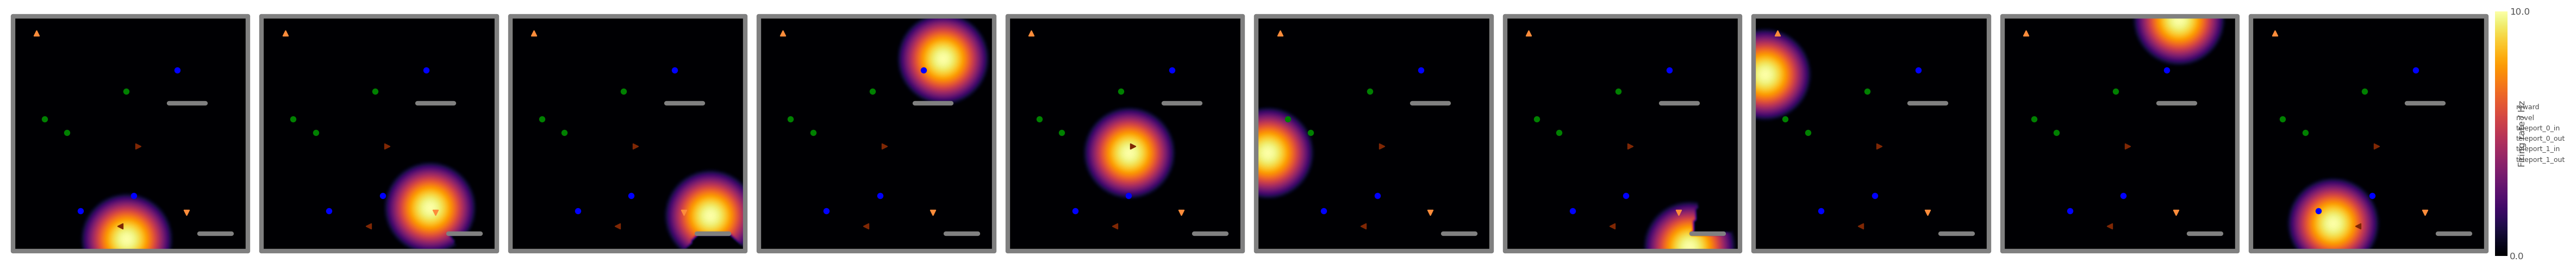

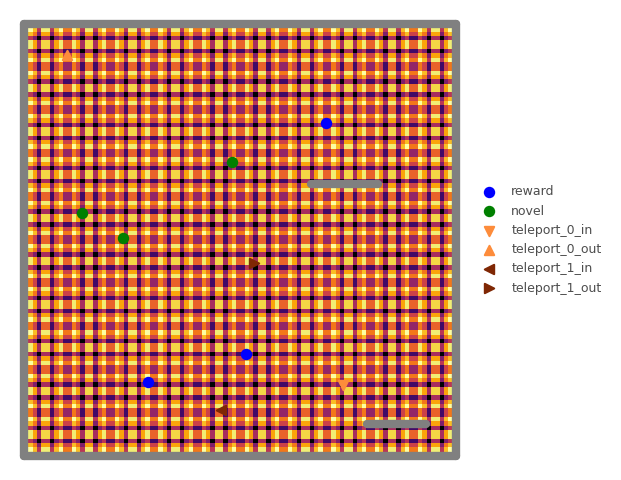

In [8]:
CA3_PCs.plot_rate_map(chosen_neurons=np.random.choice(CA3_PCs.n, 10))                                    
plot_util.plot_overlayed_rate_maps(CA3_PCs, method="max", colorbar=False);

In [9]:
num_BTSP = 0
for i in tqdm(range(MAX_NUM_STEPS)):
    Ag.update(speed_fact=3, drift_to_random_strength_ratio=1)
    ECs.update()
    CA3_PCs.update()
    CA1s.update()
    if len(CA1s.SomaCompartment.history["BTSP_events"]) > num_BTSP:
        print(f"BTSP event at step {len(CA1s.SomaCompartment.history['t'])}.")
        num_BTSP += 1
        
    if i > 8000:
        CA1s.set_BTSP_learn(soma=False, dend=False) # just capture rate maps

  1%|▍                                     | 129/12000 [00:00<00:29, 406.97it/s]

BTSP event at step 83.
BTSP event at step 161.


  2%|▊                                     | 251/12000 [00:00<00:29, 399.33it/s]

BTSP event at step 210.
BTSP event at step 258.


  3%|█▏                                    | 374/12000 [00:00<00:29, 389.53it/s]

...

 64%|███████████████████████▊             | 7735/12000 [00:19<00:10, 406.89it/s]

BTSP event at step 7676.


 76%|████████████████████████████▏        | 9135/12000 [00:22<00:06, 439.52it/s]

Teleported through pair 1 at step 9069 (272.10 sec.)


100%|████████████████████████████████████| 12000/12000 [00:29<00:00, 408.60it/s]


In [10]:
Ag.teleportation_df 

,teleport_pair_num,step_num,time,in_object_idx,in_object_type_num,in_object_type_name,in_position_x,in_position_y,in_vector_x,in_vector_y,...,in_velocity_y,out_object_idx,out_object_type_num,out_object_type_name,out_position_x,out_position_y,out_vector_x,out_vector_y,out_velocity_x,out_velocity_y
0,1,9069,272.07,8,4,teleport_1_in,0.476404,0.095467,0.020663,-0.011649,...,-0.007837,9,5,teleport_1_out,0.511909,0.457724,-0.020663,0.011649,-0.117035,-0.007837


In [11]:
Ag.target_df

,object_idx,object_type_name,object_type_num,position_x,position_y,set_step,set_time,random_walk_periods,reached_step,reached_time,num_random_walk_steps,random_walk_time,num_steps_total,time_total
0,0.0,reward,0.0,0.287125,0.172645,0,0.00,[],169.0,5.07,0.0,0.0,169.0,5.07
1,0.0,reward,0.0,0.287125,0.172645,169,5.07,[],170.0,5.10,0.0,0.0,1.0,0.03
2,1.0,reward,0.0,0.699314,0.771511,170,5.10,[],363.0,10.89,0.0,0.0,193.0,5.79
3,1.0,reward,0.0,0.699314,0.771511,363,10.89,[],364.0,10.92,0.0,0.0,1.0,0.03
4,4.0,novel,1.0,0.134185,0.561462,364,10.92,[],497.0,14.91,0.0,0.0,133.0,3.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,NaN,no_target,NaN,NaN,NaN,11217,336.51,"[[11217, 11517]]",NaN,NaN,300.0,9.0,300.0,9.00
69,2.0,reward,0.0,0.514552,0.235807,11517,345.51,[],11712.0,351.36,0.0,0.0,195.0,5.85
70,3.0,novel,1.0,0.230040,0.505715,11712,351.36,[],11825.0,354.75,0.0,0.0,113.0,3.39
71,1.0,reward,0.0,0.699314,0.771511,11825,354.75,[],11956.0,358.68,0.0,0.0,131.0,3.93


In [12]:
# start = time.perf_counter()
# t_start = 100
# anim = Ag.animate_trajectories(t_start=t_start, t_end=t_start + 15, decay_point_timescale=1) # 500 steps / 15 sec
# anim

In [13]:
# print(f"Took {(time.perf_counter() - start) / 60:.2f} min. to generate animation.")
# ratinabox.utils.save_animation(anim, "openfield_trajectory", anim_save_types=["mp4", "gif"]);

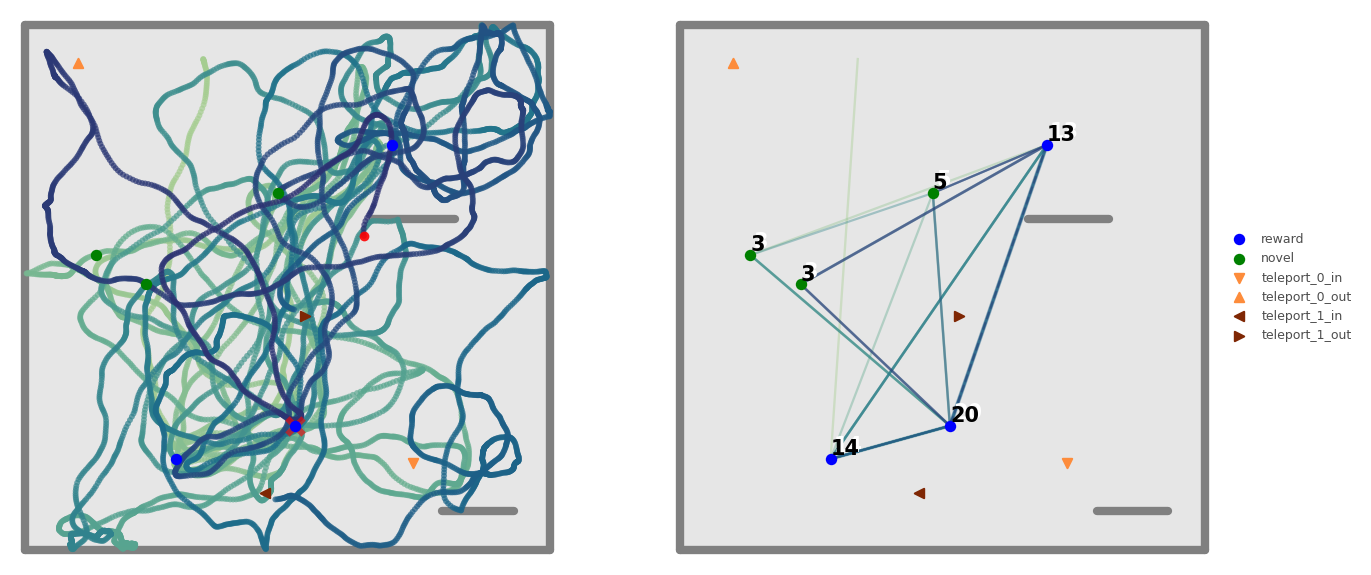

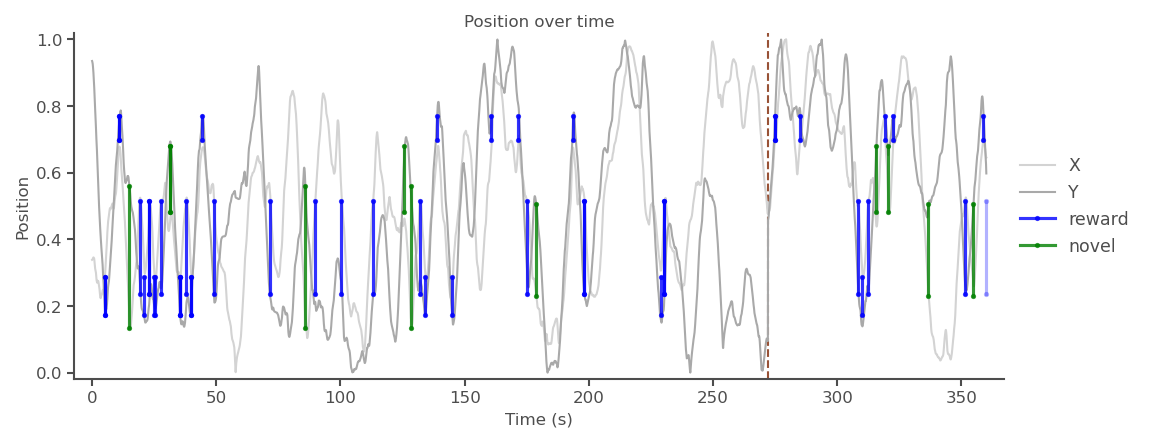

In [14]:
fig, ax1D = plt.subplots(1, 2, figsize=(8, 12))
Ag.plot_trajectories(
    cmap_per=True, scale_cmap_per=True, s_2D=8, target_alpha=0.3, 
    sub_ax=ax1D[0], t_start=0, t_end=None, framerate=100
)
ax1D[0].get_legend().remove()
Ag.plot_trajectory_targets(alpha=0.4, sub_ax=ax1D[1])
Ag.plot_trajectory_target_coords_over_time();

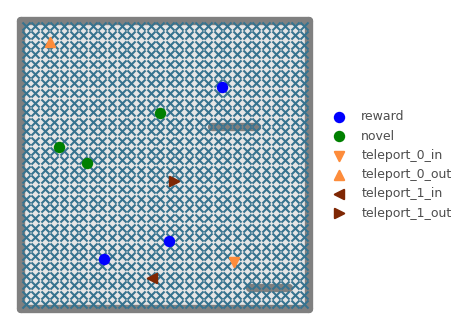

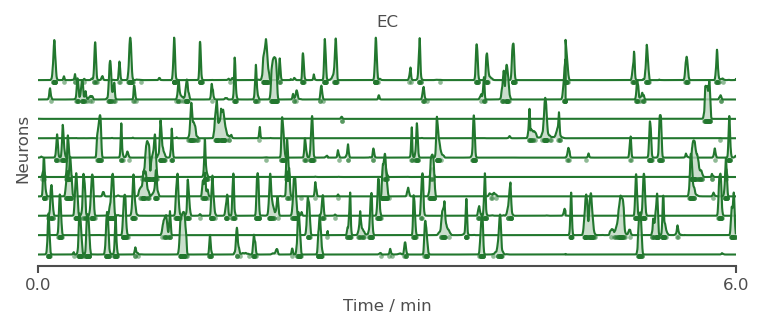

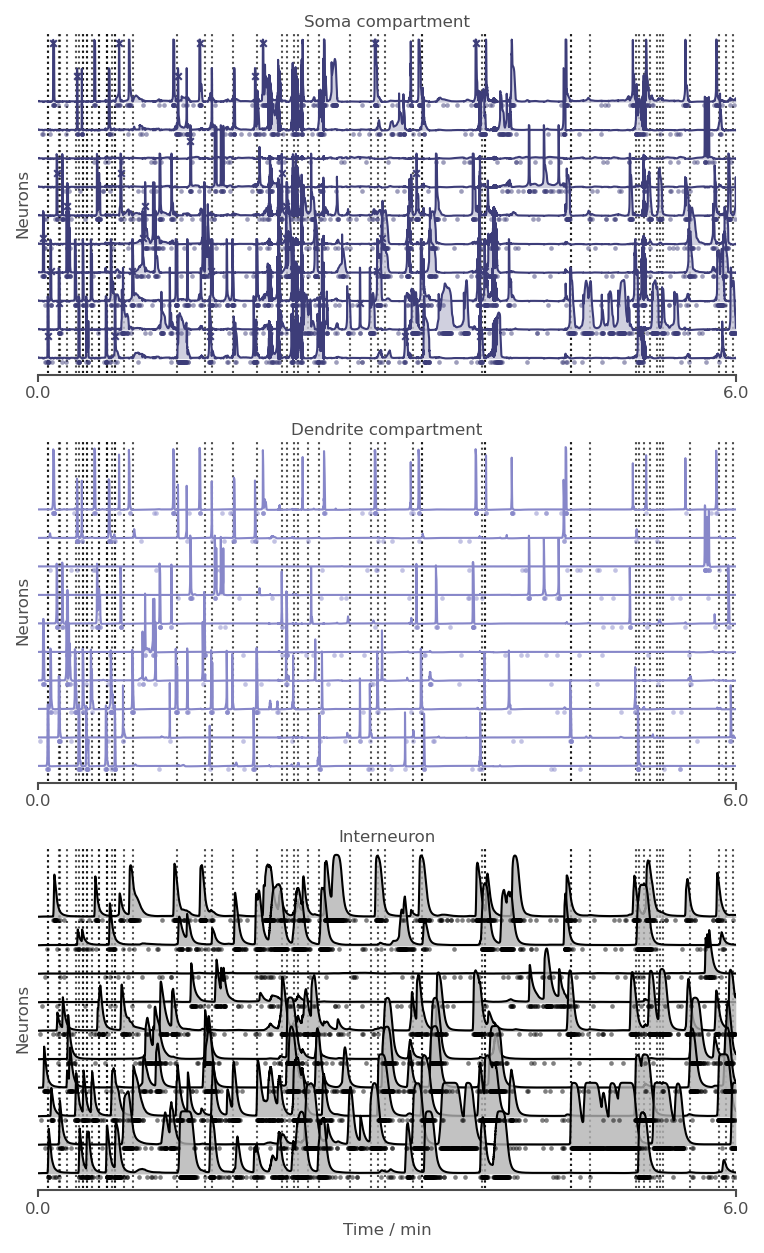

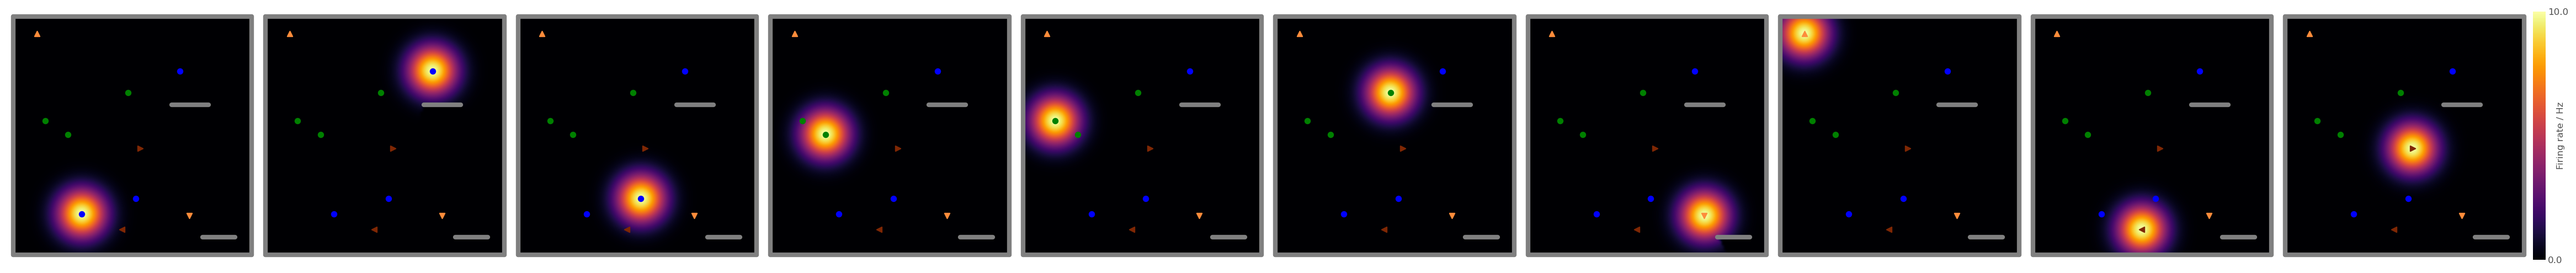

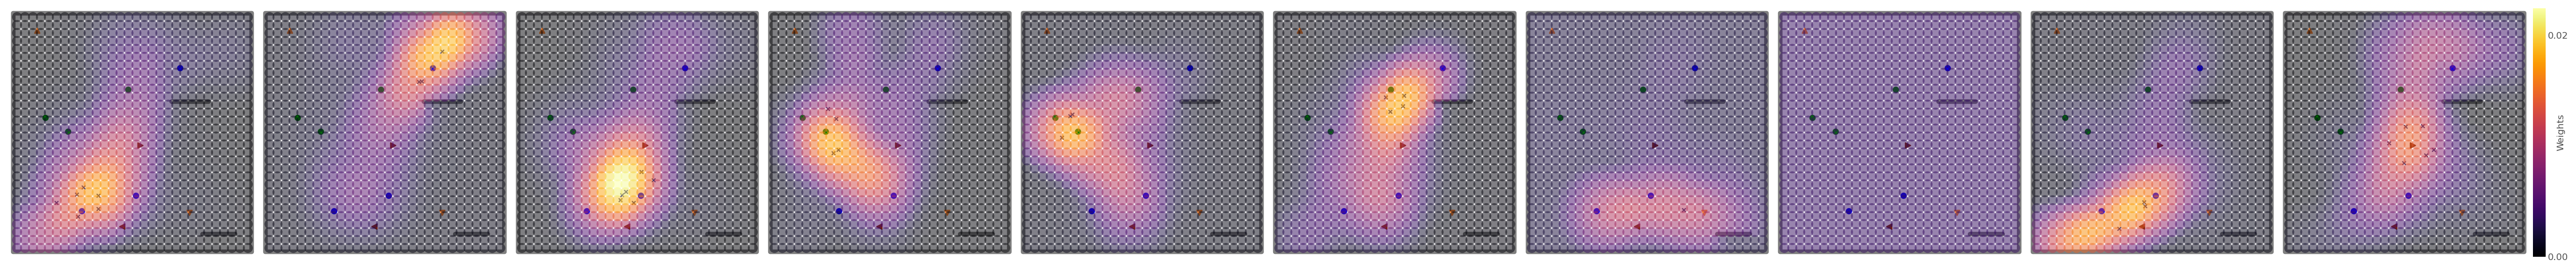

In [15]:
fig, sub_ax = plt.subplots(figsize=(3, 2))
CA3_PCs.plot_place_cell_locations(sub_ax=sub_ax)

fig, sub_ax = plt.subplots(figsize=(6, 2))
sub_ax.set_title("EC")
ECs.plot_rate_timeseries(chosen_neurons="all", spikes=True, sub_ax=sub_ax);

fig, ax = plt.subplots(3, 1, figsize=(6, 10))
CA1s.plot_rate_timeseries(chosen_neurons="all", spikes=True, separate_axes=True, ax=ax)

ECs.plot_rate_map(shape=(ECs.n, 1), no_legend=True)
plot_util.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, alpha=0.5, plot_BTSP_events=True, no_legend=True);

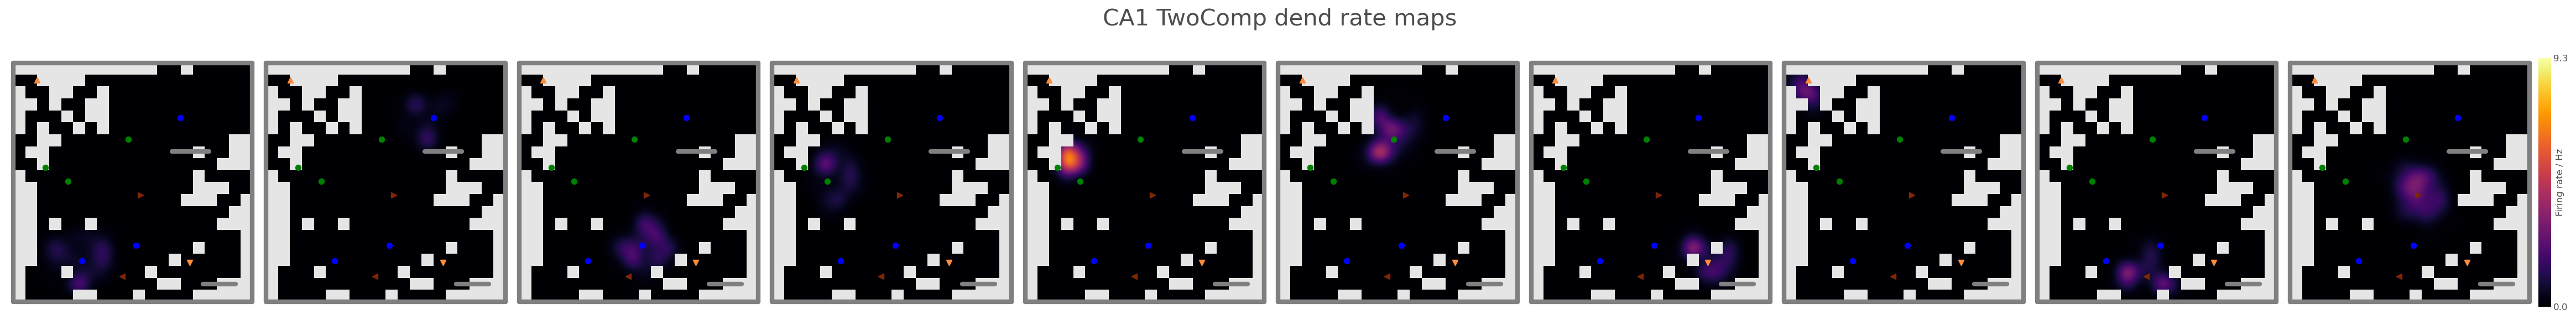

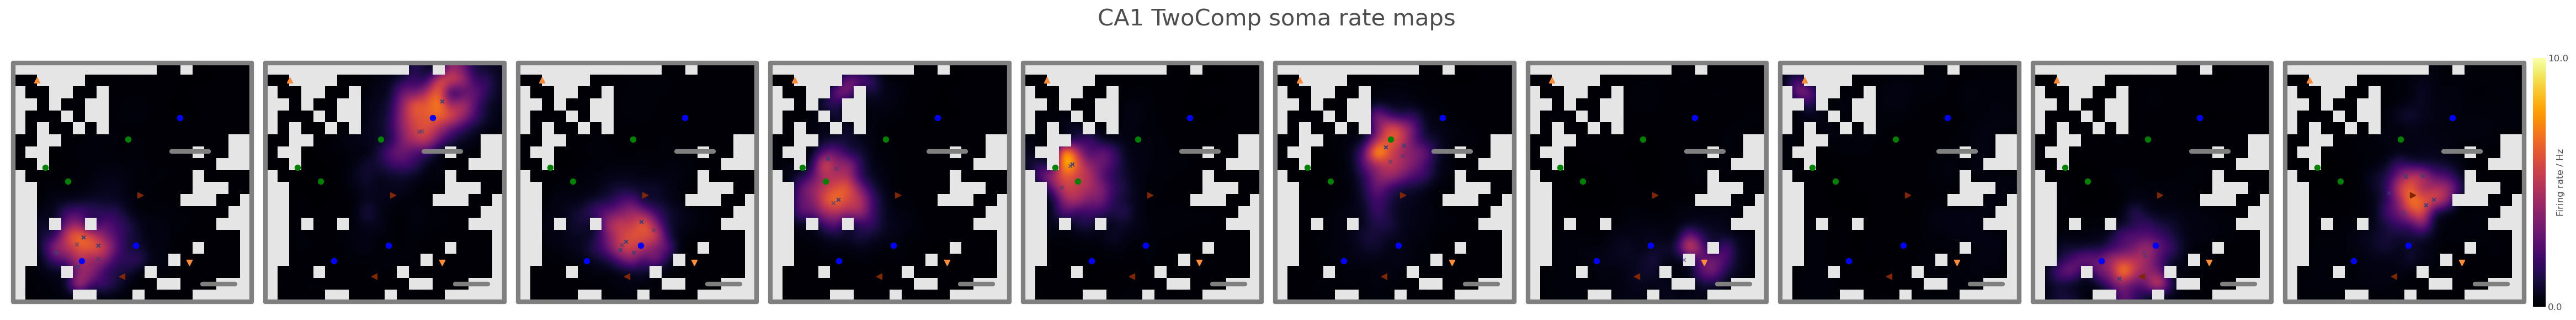

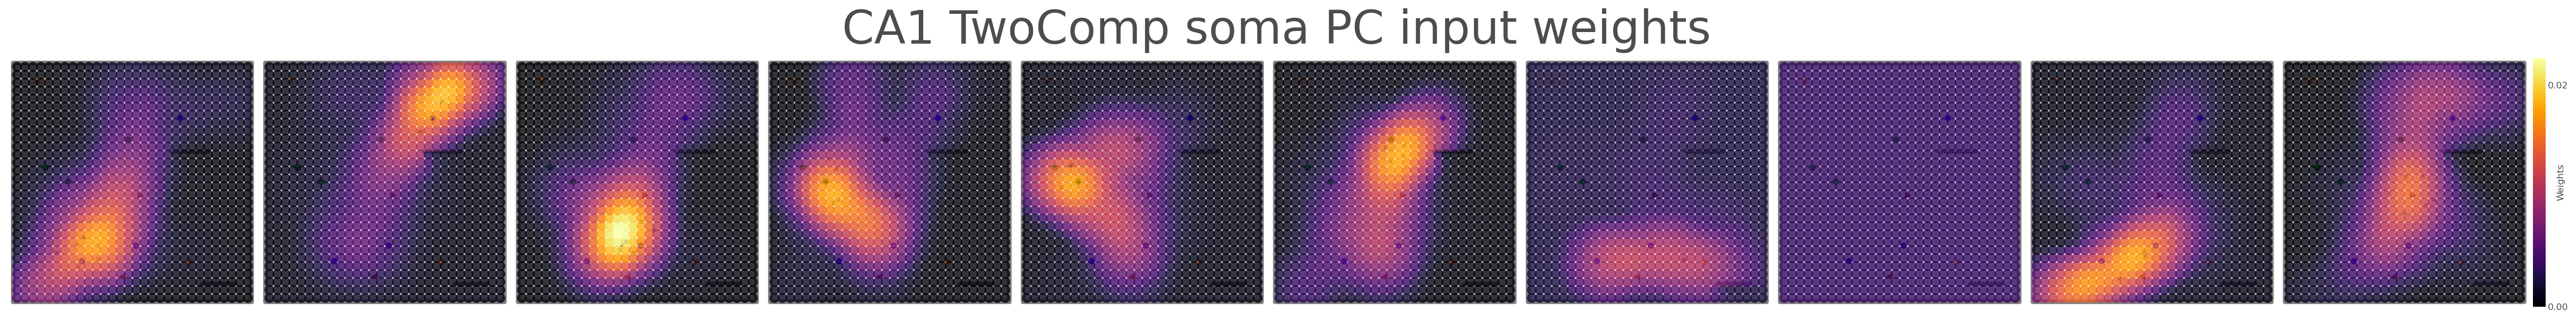

In [16]:
for CA1s_comp in [CA1s.DendriteCompartment, CA1s.SomaCompartment]:
    axes = CA1s_comp.plot_rate_map(method="history", t_start=80, no_legend=True)
    name = CA1s_comp.name.replace("_", " ")
    axes.ravel()[0].figure.suptitle(f"{name} rate maps", y=1.2, fontsize=20);

axes = plot_util.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, alpha=0.8, plot_BTSP_events=True, no_legend=True)
name = CA1s_comp.name.replace("_", " ")
axes.ravel()[0].figure.suptitle(f"{name} PC input weights", y=1.2, fontsize=40);

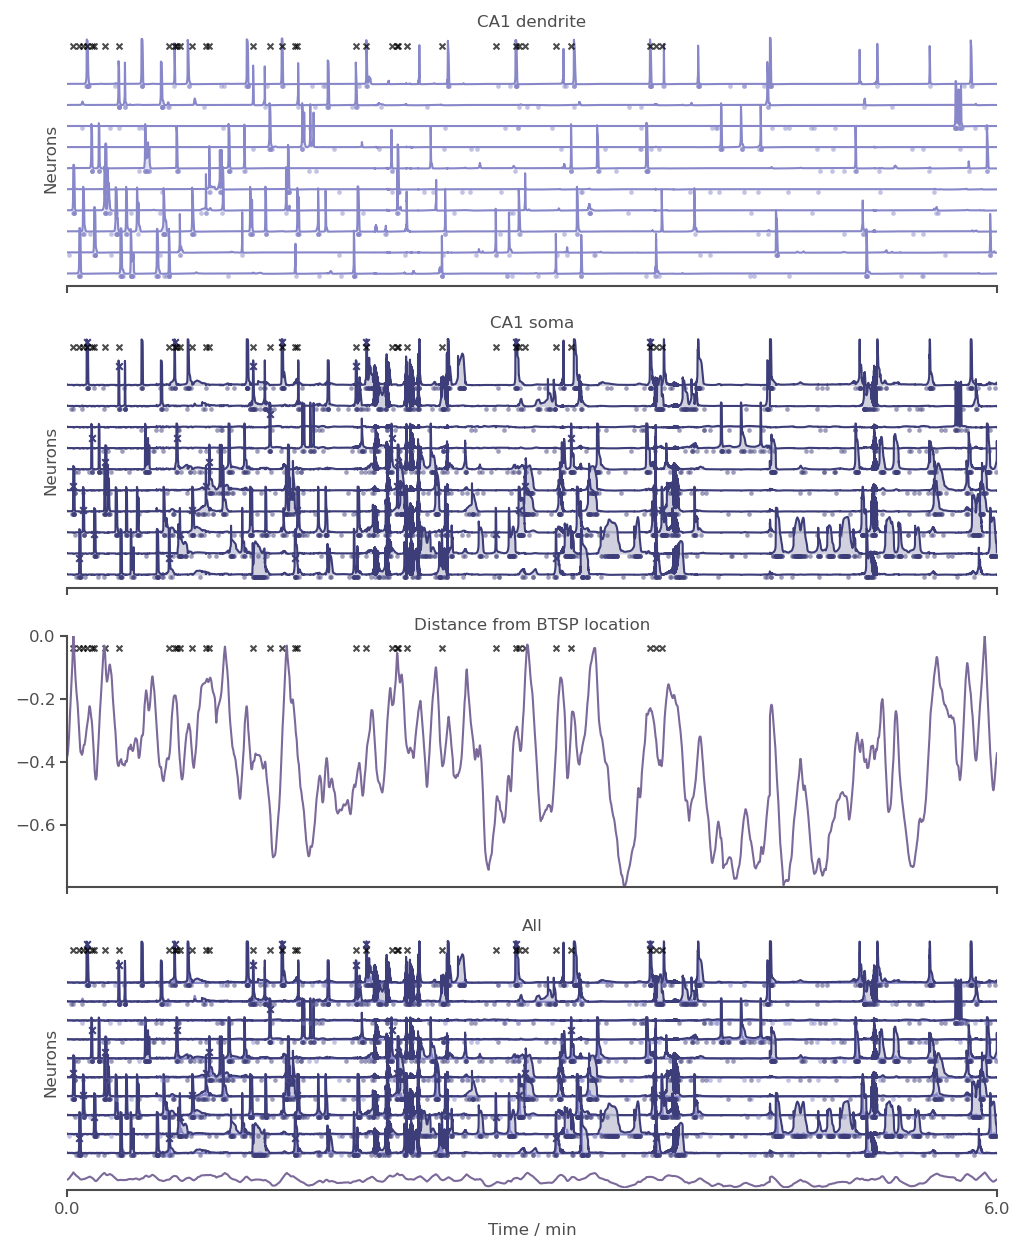

In [17]:
fig, ax1D = plt.subplots(4, 1, figsize=[8, 10], sharex=True, sharey=False)

CA1s.DendriteCompartment.plot_rate_timeseries(sub_ax=ax1D[0], chosen_neurons="all", spikes=True)
CA1s.SomaCompartment.plot_rate_timeseries(sub_ax=ax1D[1], chosen_neurons="all", spikes=True)

if len(CA1s.SomaCompartment.history["BTSP_events"]):
    BTSP_loc = Ag.history["pos"][CA1s.SomaCompartment.history["BTSP_events"][0]]
    all_pos = np.asarray(Ag.history["pos"])
    time_min = np.asarray(Ag.history["t"]) / 60
    distances = np.linalg.norm(BTSP_loc - all_pos, ord=2, axis=1)
    ax1D[2].plot(time_min, -distances)
    ax1D[2].spines[["right", "top"]].set_visible(False)

CA1s.DendriteCompartment.plot_rate_timeseries(sub_ax=ax1D[3], chosen_neurons="all", spikes=True)
CA1s.SomaCompartment.plot_rate_timeseries(sub_ax=ax1D[3], chosen_neurons="all", spikes=True)

if len(CA1s.SomaCompartment.history["BTSP_events"]):
    bot, top = ax1D[3].get_ylim()
    ax1D[3].plot(time_min, -distances)
    ax1D[3].set_ylim(-distances.max() * 1.05, None)

for t in CA1s.SomaCompartment.history["BTSP_events"]:
    for i in range(4):
        lo, hi = ax1D[i].get_ylim()
        y_hei = lo + (hi - lo) * 0.95
        ax1D[i].scatter(
            CA1s.SomaCompartment.history["t"][t] / 60, y_hei, marker="x", s=8, 
            color="k", alpha=0.7
        )

ax1D[0].set_title("CA1 dendrite")
ax1D[0].set_xlabel("")
ax1D[1].set_title("CA1 soma")
ax1D[1].set_xlabel("")
ax1D[2].set_title("Distance from BTSP location")
ax1D[2].set_xlabel("")
ax1D[3].set_title("All");